# Potential Talent: Candidate Ranking with Text Similarity

## Background

A talent-sourcing company needs to understand a client's role, identify what makes a candidate relevant, and rank potential candidates. This notebook explores job-title similarity as a first step toward that ranking system.

## Notebook flow

1. Load and inspect the data
2. Remove duplicate job titles
3. Clean and audit the text
4. Build a Bag-of-Words baseline
5. Build a TF-IDF model
6. Add Word2Vec, GloVe, FastText, BERT, and SBERT
7. Re-rank from recruiter stars and rejections
8. Compare all models with cosine similarity


In [52]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [53]:
df = pd.read_excel("potential-talents.xlsx")


## 1. Data overview

Start with the dataset size, a sample of its rows, data types, missing values, and unique-value counts.


In [54]:
print("Dataset shape:", df.shape)
display(df.head())

column_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(dropna=False),
})

display(column_summary)


Dataset shape: (104, 5)


,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


,dtype,missing_values,unique_values
id,int64,0,104
job_title,str,0,52
location,str,0,41
connection,object,0,33
fit,float64,104,1


## 2. Duplicate job titles

Repeated titles would give some documents extra influence. Inspect them first, then keep one row per cleaned job title during preprocessing.


In [55]:
duplicate_mask = df.duplicated(subset="job_title", keep=False)
duplicate_rows = df.loc[duplicate_mask].sort_values("job_title")

print("Rows involved in exact job-title duplicates:", duplicate_mask.sum())
print("Unique original job titles:", df["job_title"].nunique())
display(duplicate_rows[["id", "job_title"]].head(20))


Rows involved in exact job-title duplicates: 66
Unique original job titles: 52


,id,job_title
0,1,2019 C.T. Bauer College of Business Graduate (...
13,14,2019 C.T. Bauer College of Business Graduate (...
14,15,2019 C.T. Bauer College of Business Graduate (...
18,19,2019 C.T. Bauer College of Business Graduate (...
30,31,2019 C.T. Bauer College of Business Graduate (...
43,44,2019 C.T. Bauer College of Business Graduate (...
56,57,2019 C.T. Bauer College of Business Graduate (...
4,5,Advisory Board Member at Celal Bayar University
22,23,Advisory Board Member at Celal Bayar University
34,35,Advisory Board Member at Celal Bayar University


## 3. Text preprocessing

Two text versions are retained for comparison:

- `job_title_cleaned`: fixes line breaks and repeated whitespace while preserving readable text.
- `job_title_model`: lowercases text and removes noise for both Bag of Words and TF-IDF.


In [56]:
def basic_clean(text):
    if pd.isna(text):
        return ""

    text = str(text).replace("\n", " ")
    return re.sub(r"\s+", " ", text).strip()


def clean_for_vectorizers(text):
    text = basic_clean(text).lower()

    # Remove phone numbers.
    text = re.sub(r"\(?\d{3}\)?[-\s]?\d{3}[-\s]?\d{4}", " ", text)

    # Keep ASCII letters and numbers; punctuation becomes a word boundary.
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df_cleaned = df.copy()
df_cleaned["job_title_cleaned"] = df_cleaned["job_title"].apply(basic_clean)
df_cleaned["job_title_model"] = df_cleaned["job_title_cleaned"].apply(
    clean_for_vectorizers
)

df_cleaned = (
    df_cleaned
    .drop_duplicates(subset="job_title_cleaned", keep="first")
    .reset_index(drop=True)
)

print("Rows before deduplication:", len(df))
print("Rows after deduplication:", len(df_cleaned))
display(df_cleaned[["job_title", "job_title_cleaned", "job_title_model"]].head(10))


Rows before deduplication: 104
Rows after deduplication: 52


,job_title,job_title_cleaned,job_title_model
0,2019 C.T. Bauer College of Business Graduate (...,2019 C.T. Bauer College of Business Graduate (...,2019 c t bauer college of business graduate ma...
1,Native English Teacher at EPIK (English Progra...,Native English Teacher at EPIK (English Progra...,native english teacher at epik english program...
2,Aspiring Human Resources Professional,Aspiring Human Resources Professional,aspiring human resources professional
3,People Development Coordinator at Ryan,People Development Coordinator at Ryan,people development coordinator at ryan
4,Advisory Board Member at Celal Bayar University,Advisory Board Member at Celal Bayar University,advisory board member at celal bayar university
5,Aspiring Human Resources Specialist,Aspiring Human Resources Specialist,aspiring human resources specialist
6,Student at Humber College and Aspiring Human R...,Student at Humber College and Aspiring Human R...,student at humber college and aspiring human r...
7,HR Senior Specialist,HR Senior Specialist,hr senior specialist
8,Seeking Human Resources HRIS and Generalist Po...,Seeking Human Resources HRIS and Generalist Po...,seeking human resources hris and generalist po...
9,Student at Chapman University,Student at Chapman University,student at chapman university


### Cleaning audit

Compare text using the same default token rule as scikit-learn's word vectorizers: lowercase tokens containing at least two word characters. This prevents capitalization changes from being mislabeled as lost words.


In [57]:
token_pattern = re.compile(r"(?u)\b\w\w+\b")


def tokenize(text):
    return token_pattern.findall(str(text).lower())


audit_columns = ["job_title", "job_title_cleaned", "job_title_model"]

cleaning_summary = pd.DataFrame({
    "total_tokens": {
        column: df_cleaned[column].apply(lambda text: len(tokenize(text))).sum()
        for column in audit_columns
    },
    "unique_tokens": {
        column: len({
            token
            for text in df_cleaned[column]
            for token in tokenize(text)
        })
        for column in audit_columns
    },
})

original_vocabulary = {
    token for text in df_cleaned["job_title"] for token in tokenize(text)
}
model_vocabulary = {
    token for text in df_cleaned["job_title_model"] for token in tokenize(text)
}

display(cleaning_summary)
print("Tokens removed by model cleaning:", sorted(original_vocabulary - model_vocabulary))
print("Tokens introduced by model cleaning:", sorted(model_vocabulary - original_vocabulary))


,total_tokens,unique_tokens
job_title,393,200
job_title_cleaned,393,200
job_title_model,390,197


Tokens removed by model cleaning: ['2621', '408', '709']
Tokens introduced by model cleaning: []


## 4. Text vectorization and similarity

Both models follow the same ranking pipeline:

```text
Cleaned job titles → numerical document vectors
Recruiter query     → numerical query vector
Query and documents → cosine-similarity scores → ranked candidates
```

Bag of Words uses raw token counts. TF-IDF starts with the same counts but reduces the influence of tokens that occur in many documents.


In [58]:
search_query = "aspiring human resources professional"
cleaned_query = clean_for_vectorizers(search_query)


def rank_query(vectorizer, document_matrix, query):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, document_matrix).ravel()

    results = df_cleaned[["job_title"]].copy()
    results["cosine_similarity"] = scores
    return results.sort_values("cosine_similarity", ascending=False)


def plot_similarity_map(similarity_matrix, title, color_map):
    plt.figure(figsize=(10, 8))
    plt.imshow(similarity_matrix, cmap=color_map, vmin=0, vmax=1)
    plt.colorbar(label="Cosine similarity")
    plt.title(title)
    plt.xlabel("Job-title row")
    plt.ylabel("Job-title row")
    plt.tight_layout()
    plt.show()


print("Original query:", search_query)
print("Cleaned query:", cleaned_query)


Original query: aspiring human resources professional
Cleaned query: aspiring human resources professional


### 4.1 Bag of Words

`CountVectorizer` creates a document-term matrix. Rows represent job titles, columns represent vocabulary terms, and values are raw token counts.


Bag-of-Words matrix shape: (52, 197)


,job_title,human,resources,at,and,aspiring,seeking,professional,manager,student,in,management,university,of,business,generalist
0,2019 C.T. Bauer College of Business Graduate (...,1,1,0,1,1,0,1,0,0,0,0,0,1,1,0
1,Native English Teacher at EPIK (English Progra...,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
2,Aspiring Human Resources Professional,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0
3,People Development Coordinator at Ryan,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,Advisory Board Member at Celal Bayar University,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
5,Aspiring Human Resources Specialist,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0
6,Student at Humber College and Aspiring Human R...,1,1,1,1,1,0,0,0,1,0,0,0,0,0,1
7,HR Senior Specialist,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,Seeking Human Resources HRIS and Generalist Po...,1,1,0,1,0,1,0,0,0,0,0,0,0,0,1
9,Student at Chapman University,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0


,word,frequency
0,human,33
1,resources,33
2,at,22
3,and,13
4,aspiring,12
5,seeking,10
6,professional,8
7,manager,7
8,student,6
9,in,6


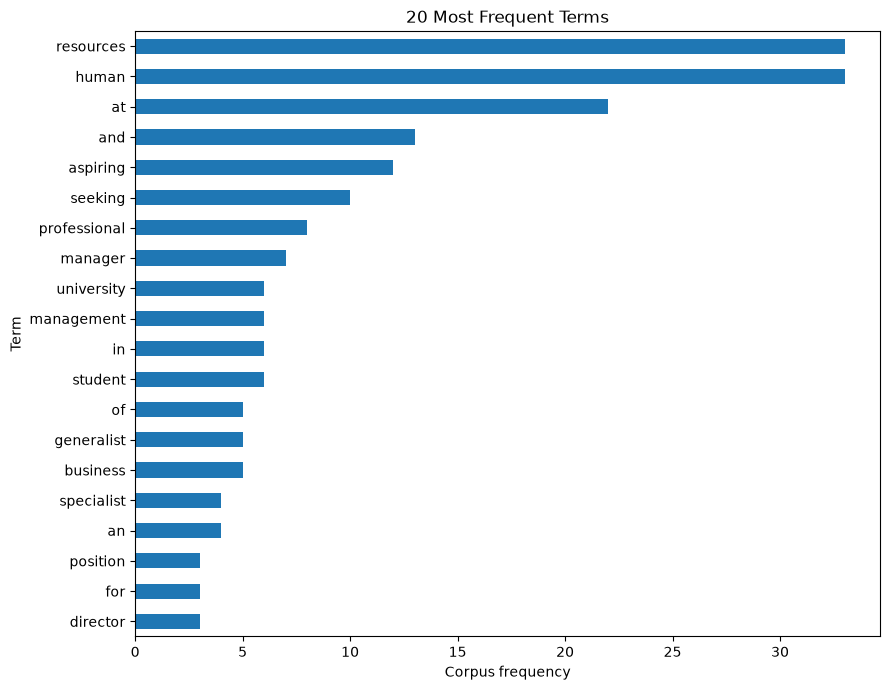

In [59]:
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(df_cleaned["job_title_model"])
bow_terms = bow_vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_terms,
    index=df_cleaned.index,
)

bow_frequency = (
    bow_df.sum()
    .sort_values(ascending=False)
    .rename_axis("word")
    .reset_index(name="frequency")
)

top_bow_terms = bow_frequency.head(15)["word"].tolist()
bow_preview = df_cleaned[["job_title"]].join(bow_df[top_bow_terms])

print("Bag-of-Words matrix shape:", bow_matrix.shape)
display(bow_preview.head(10))
display(bow_frequency.head(20))

bow_frequency.head(20).sort_values("frequency").plot(
    kind="barh",
    x="word",
    y="frequency",
    figsize=(9, 7),
    legend=False,
    title="20 Most Frequent Terms",
)
plt.xlabel("Corpus frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


,job_title,cosine_similarity
2,Aspiring Human Resources Professional,1.000000
22,Human Resources Professional,0.866025
5,Aspiring Human Resources Specialist,0.750000
14,Experienced Retail Manager and aspiring Human ...,0.707107
21,"Aspiring Human Resources Manager, seeking inte...",0.693375
30,Aspiring Human Resources Professional | An ene...,0.632456
15,"Human Resources, Staffing and Recruiting Profe...",0.612372
27,Liberal Arts Major. Aspiring Human Resources A...,0.566947
47,Aspiring Human Resources Manager | Graduating ...,0.545545
0,2019 C.T. Bauer College of Business Graduate (...,0.534522


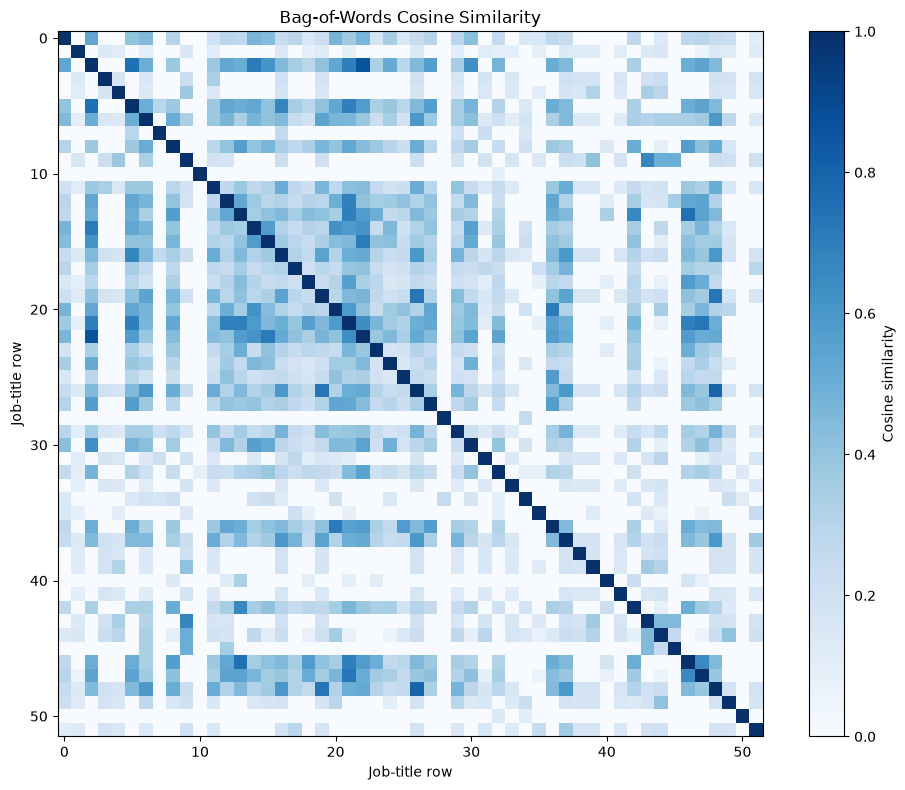

In [60]:
bow_similarity_matrix = cosine_similarity(bow_matrix)
bow_results = rank_query(bow_vectorizer, bow_matrix, cleaned_query)

display(bow_results.head(10))
plot_similarity_map(
    bow_similarity_matrix,
    "Bag-of-Words Cosine Similarity",
    "Blues",
)


### 4.2 TF-IDF

`TfidfVectorizer` uses the same document-term structure but gives less weight to common terms and more weight to terms that are distinctive within the corpus.


In [61]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_cleaned["job_title_model"])
tfidf_terms = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_terms,
    index=df_cleaned.index,
)

mean_tfidf = (
    tfidf_df.mean()
    .sort_values(ascending=False)
    .rename_axis("word")
    .reset_index(name="mean_tfidf")
)

top_tfidf_terms = mean_tfidf.head(15)["word"].tolist()
tfidf_preview = df_cleaned[["job_title"]].join(tfidf_df[top_tfidf_terms])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
display(tfidf_preview.head(10))
display(mean_tfidf.head(20))


TF-IDF matrix shape: (52, 197)


,job_title,human,resources,at,aspiring,and,seeking,professional,student,generalist,management,manager,specialist,university,business,in
0,2019 C.T. Bauer College of Business Graduate (...,0.115414,0.115414,0.000000,0.184514,0.184514,0.000000,0.212722,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.243825,0.000000
1,Native English Teacher at EPIK (English Progra...,0.000000,0.000000,0.141124,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.227119
2,Aspiring Human Resources Professional,0.354598,0.354598,0.000000,0.566898,0.000000,0.000000,0.653565,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,People Development Coordinator at Ryan,0.000000,0.000000,0.219344,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,Advisory Board Member at Celal Bayar University,0.000000,0.000000,0.184144,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.296354,0.000000,0.000000
5,Aspiring Human Resources Specialist,0.323666,0.323666,0.000000,0.517447,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.723000,0.000000,0.000000,0.000000
6,Student at Humber College and Aspiring Human R...,0.177112,0.177112,0.221220,0.283150,0.283150,0.000000,0.000000,0.356021,0.374167,0.0,0.0,0.000000,0.000000,0.000000,0.000000
7,HR Senior Specialist,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.523125,0.000000,0.000000,0.000000
8,Seeking Human Resources HRIS and Generalist Po...,0.188628,0.188628,0.000000,0.000000,0.301561,0.322505,0.000000,0.000000,0.398497,0.0,0.0,0.000000,0.000000,0.000000,0.000000
9,Student at Chapman University,0.000000,0.000000,0.296693,0.000000,0.000000,0.000000,0.000000,0.477485,0.000000,0.0,0.0,0.000000,0.477485,0.000000,0.000000


,word,mean_tfidf
0,human,0.127601
1,resources,0.127601
2,at,0.092735
3,aspiring,0.069666
4,and,0.061522
5,seeking,0.060002
6,professional,0.059853
7,student,0.054648
8,generalist,0.043367
9,management,0.041929


,job_title,cosine_similarity
2,Aspiring Human Resources Professional,1.000000
22,Human Resources Professional,0.823788
14,Experienced Retail Manager and aspiring Human ...,0.524548
5,Aspiring Human Resources Specialist,0.522882
21,"Aspiring Human Resources Manager, seeking inte...",0.440639
30,Aspiring Human Resources Professional | An ene...,0.414161
15,"Human Resources, Staffing and Recruiting Profe...",0.402068
0,2019 C.T. Bauer College of Business Graduate (...,0.325479
20,Business Management Major and Aspiring Human R...,0.320520
12,Aspiring Human Resources Management student se...,0.307536


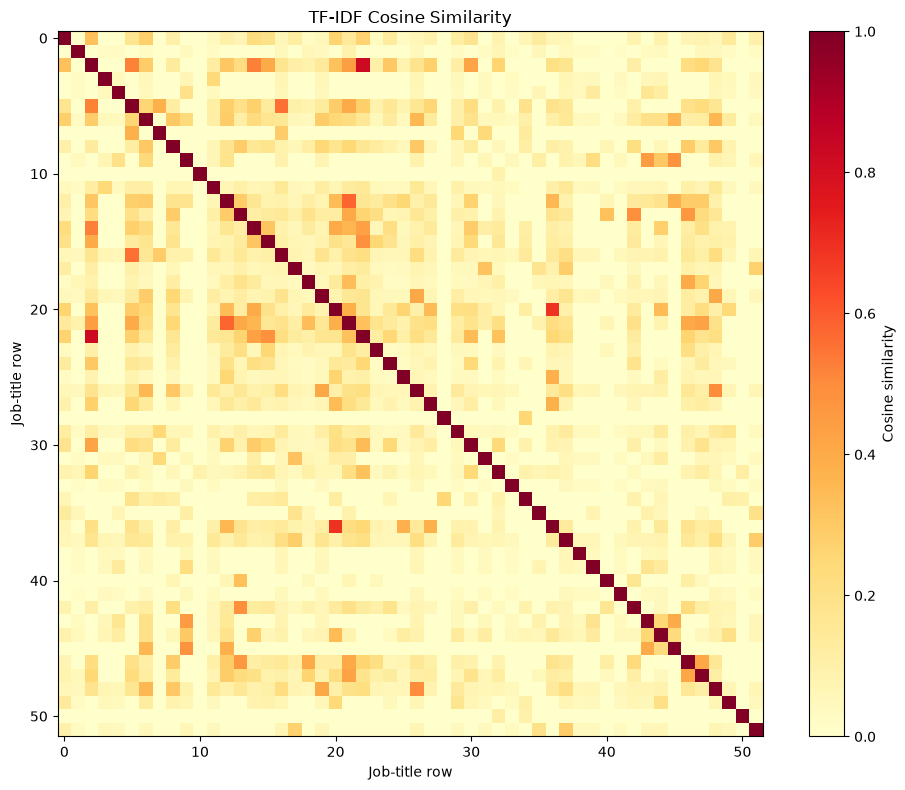

In [62]:
tfidf_similarity_matrix = cosine_similarity(tfidf_matrix)
tfidf_results = rank_query(tfidf_vectorizer, tfidf_matrix, cleaned_query)

display(tfidf_results.head(10))
plot_similarity_map(
    tfidf_similarity_matrix,
    "TF-IDF Cosine Similarity",
    "YlOrRd",
)


## 5. Dense word embeddings

Word2Vec, GloVe, and FastText learn one dense vector per word. A job-title vector is created by averaging its word vectors, then cosine similarity is applied as before.

> **Training limitation:** this notebook trains these three models locally for learning purposes. The corpus has only 52 unique titles, so their rankings are demonstrations rather than reliable production results. Real projects should use much larger training data or suitable pretrained vectors.


In [63]:
import torch
from torch import nn
from torch.nn import functional as F

torch.manual_seed(42)
np.random.seed(42)

tokenized_titles = [tokenize(text) for text in df_cleaned["job_title_model"]]
embedding_vocabulary = sorted({token for title in tokenized_titles for token in title})
word_to_id = {word: index for index, word in enumerate(embedding_vocabulary)}
id_to_word = {index: word for word, index in word_to_id.items()}


def make_skipgram_pairs(tokenized_documents, window_size=2):
    pairs = []
    for document in tokenized_documents:
        token_ids = [word_to_id[token] for token in document]
        for center_position, center_id in enumerate(token_ids):
            left = max(0, center_position - window_size)
            right = min(len(token_ids), center_position + window_size + 1)
            for context_position in range(left, right):
                if center_position != context_position:
                    pairs.append((center_id, token_ids[context_position]))
    return torch.tensor(pairs, dtype=torch.long)


skipgram_pairs = make_skipgram_pairs(tokenized_titles)


def average_title_embeddings(texts, word_vectors, vocabulary_lookup):
    embeddings = []
    vector_size = word_vectors.shape[1]

    for text in texts:
        token_ids = [vocabulary_lookup[token] for token in tokenize(text)
                     if token in vocabulary_lookup]
        if token_ids:
            embeddings.append(word_vectors[token_ids].mean(axis=0))
        else:
            embeddings.append(np.zeros(vector_size, dtype=np.float32))

    return np.vstack(embeddings)


def rank_dense_embeddings(document_embeddings, query_embedding, score_name):
    scores = cosine_similarity(query_embedding.reshape(1, -1), document_embeddings).ravel()
    results = df_cleaned[["job_title"]].copy()
    results[score_name] = scores
    return results.sort_values(score_name, ascending=False)


print("Embedding vocabulary size:", len(embedding_vocabulary))
print("Skip-gram training pairs:", len(skipgram_pairs))


Embedding vocabulary size: 197
Skip-gram training pairs: 1250


### 5.1 Word2Vec

This is a small skip-gram model: a center word is used to predict nearby context words. The learned embedding table provides the word vectors.


In [64]:
class Word2VecSkipGram(nn.Module):
    def __init__(self, vocabulary_size, vector_size):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocabulary_size, vector_size)
        self.context_projection = nn.Linear(vector_size, vocabulary_size)

    def forward(self, center_words):
        return self.context_projection(self.word_embeddings(center_words))


word2vec_model = Word2VecSkipGram(
    vocabulary_size=len(embedding_vocabulary),
    vector_size=50,
)
word2vec_optimizer = torch.optim.Adam(word2vec_model.parameters(), lr=0.03)

center_words = skipgram_pairs[:, 0]
context_words = skipgram_pairs[:, 1]

for epoch in range(150):
    word2vec_optimizer.zero_grad()
    predictions = word2vec_model(center_words)
    word2vec_loss = F.cross_entropy(predictions, context_words)
    word2vec_loss.backward()
    word2vec_optimizer.step()

word2vec_vectors = word2vec_model.word_embeddings.weight.detach().numpy()
word2vec_title_embeddings = average_title_embeddings(
    df_cleaned["job_title_model"], word2vec_vectors, word_to_id
)
word2vec_query_embedding = average_title_embeddings(
    [cleaned_query], word2vec_vectors, word_to_id
)[0]
word2vec_results = rank_dense_embeddings(
    word2vec_title_embeddings,
    word2vec_query_embedding,
    "word2vec_similarity",
)

print("Final Word2Vec training loss:", round(word2vec_loss.item(), 4))
display(word2vec_results.head(10))


Final Word2Vec training loss: 2.038


,job_title,word2vec_similarity
2,Aspiring Human Resources Professional,1.000000
5,Aspiring Human Resources Specialist,0.874233
22,Human Resources Professional,0.872890
15,"Human Resources, Staffing and Recruiting Profe...",0.836280
21,"Aspiring Human Resources Manager, seeking inte...",0.831643
14,Experienced Retail Manager and aspiring Human ...,0.806970
12,Aspiring Human Resources Management student se...,0.806706
8,Seeking Human Resources HRIS and Generalist Po...,0.796150
13,Seeking Human Resources Opportunities,0.776117
20,Business Management Major and Aspiring Human R...,0.766594


### 5.2 GloVe

GloVe learns vectors from a global word co-occurrence matrix. Words appearing near one another across the corpus receive related representations.


In [65]:
cooccurrence = np.zeros(
    (len(embedding_vocabulary), len(embedding_vocabulary)),
    dtype=np.float32,
)

window_size = 2
for document in tokenized_titles:
    token_ids = [word_to_id[token] for token in document]
    for center_position, center_id in enumerate(token_ids):
        left = max(0, center_position - window_size)
        right = min(len(token_ids), center_position + window_size + 1)
        for context_position in range(left, right):
            if center_position != context_position:
                distance = abs(center_position - context_position)
                cooccurrence[center_id, token_ids[context_position]] += 1 / distance

cooccurrence_rows, cooccurrence_columns = np.nonzero(cooccurrence)
cooccurrence_values = cooccurrence[cooccurrence_rows, cooccurrence_columns]

glove_rows = torch.tensor(cooccurrence_rows, dtype=torch.long)
glove_columns = torch.tensor(cooccurrence_columns, dtype=torch.long)
glove_values = torch.tensor(cooccurrence_values, dtype=torch.float32)


class GloveModel(nn.Module):
    def __init__(self, vocabulary_size, vector_size):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocabulary_size, vector_size)
        self.context_embeddings = nn.Embedding(vocabulary_size, vector_size)
        self.word_bias = nn.Embedding(vocabulary_size, 1)
        self.context_bias = nn.Embedding(vocabulary_size, 1)

    def forward(self, word_ids, context_ids):
        interaction = (
            self.word_embeddings(word_ids)
            * self.context_embeddings(context_ids)
        ).sum(dim=1)
        return (
            interaction
            + self.word_bias(word_ids).squeeze(1)
            + self.context_bias(context_ids).squeeze(1)
        )


glove_model = GloveModel(len(embedding_vocabulary), vector_size=50)
glove_optimizer = torch.optim.Adam(glove_model.parameters(), lr=0.03)
glove_weights = torch.clamp((glove_values / 10.0) ** 0.75, max=1.0)

for epoch in range(250):
    glove_optimizer.zero_grad()
    glove_predictions = glove_model(glove_rows, glove_columns)
    glove_loss = (
        glove_weights * (glove_predictions - torch.log(glove_values)) ** 2
    ).mean()
    glove_loss.backward()
    glove_optimizer.step()

glove_vectors = (
    glove_model.word_embeddings.weight
    + glove_model.context_embeddings.weight
).detach().numpy()
glove_title_embeddings = average_title_embeddings(
    df_cleaned["job_title_model"], glove_vectors, word_to_id
)
glove_query_embedding = average_title_embeddings(
    [cleaned_query], glove_vectors, word_to_id
)[0]
glove_results = rank_dense_embeddings(
    glove_title_embeddings,
    glove_query_embedding,
    "glove_similarity",
)

print("Final GloVe training loss:", round(glove_loss.item(), 4))
display(glove_results.head(10))


Final GloVe training loss: 0.0


,job_title,glove_similarity
2,Aspiring Human Resources Professional,1.000000
22,Human Resources Professional,0.876296
5,Aspiring Human Resources Specialist,0.761785
14,Experienced Retail Manager and aspiring Human ...,0.737956
15,"Human Resources, Staffing and Recruiting Profe...",0.723593
0,2019 C.T. Bauer College of Business Graduate (...,0.704843
21,"Aspiring Human Resources Manager, seeking inte...",0.665876
20,Business Management Major and Aspiring Human R...,0.654112
24,Aspiring Human Resources Professional | Passio...,0.645069
30,Aspiring Human Resources Professional | An ene...,0.640346


### 5.3 FastText

FastText extends a word embedding with character n-gram embeddings. This lets related spellings share information and can represent unseen words from known subword pieces.


In [66]:
def character_ngrams(word, minimum=3, maximum=5):
    bounded_word = f"<{word}>"
    return {
        bounded_word[start:start + size]
        for size in range(minimum, maximum + 1)
        for start in range(len(bounded_word) - size + 1)
    }


subword_vocabulary = sorted({
    ngram
    for word in embedding_vocabulary
    for ngram in character_ngrams(word)
})
subword_to_id = {ngram: index + 1 for index, ngram in enumerate(subword_vocabulary)}

word_subword_ids = [
    [subword_to_id[ngram] for ngram in sorted(character_ngrams(word))]
    for word in embedding_vocabulary
]
maximum_subwords = max(map(len, word_subword_ids))
subword_table = torch.zeros(
    (len(embedding_vocabulary), maximum_subwords), dtype=torch.long
)
subword_mask = torch.zeros_like(subword_table, dtype=torch.float32)

for word_id, subword_ids in enumerate(word_subword_ids):
    subword_table[word_id, :len(subword_ids)] = torch.tensor(subword_ids)
    subword_mask[word_id, :len(subword_ids)] = 1.0


class FastTextSkipGram(nn.Module):
    def __init__(self, vocabulary_size, subword_count, vector_size):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocabulary_size, vector_size)
        self.subword_embeddings = nn.Embedding(
            subword_count + 1, vector_size, padding_idx=0
        )
        self.context_projection = nn.Linear(vector_size, vocabulary_size)

    def word_vectors(self, word_ids):
        selected_subwords = subword_table[word_ids]
        selected_mask = subword_mask[word_ids].unsqueeze(2)
        subword_vectors = self.subword_embeddings(selected_subwords)
        subword_average = (
            (subword_vectors * selected_mask).sum(dim=1)
            / selected_mask.sum(dim=1).clamp(min=1)
        )
        return self.word_embeddings(word_ids) + subword_average

    def forward(self, center_word_ids):
        return self.context_projection(self.word_vectors(center_word_ids))


fasttext_model = FastTextSkipGram(
    len(embedding_vocabulary),
    len(subword_vocabulary),
    vector_size=50,
)
fasttext_optimizer = torch.optim.Adam(fasttext_model.parameters(), lr=0.03)

for epoch in range(150):
    fasttext_optimizer.zero_grad()
    fasttext_predictions = fasttext_model(center_words)
    fasttext_loss = F.cross_entropy(fasttext_predictions, context_words)
    fasttext_loss.backward()
    fasttext_optimizer.step()

all_word_ids = torch.arange(len(embedding_vocabulary))
fasttext_vectors = fasttext_model.word_vectors(all_word_ids).detach().numpy()


def fasttext_token_vector(token):
    if token in word_to_id:
        return fasttext_vectors[word_to_id[token]]

    # Build an unseen word from character n-grams learned during training.
    known_subwords = [
        subword_to_id[ngram]
        for ngram in character_ngrams(token)
        if ngram in subword_to_id
    ]
    if not known_subwords:
        return np.zeros(fasttext_vectors.shape[1], dtype=np.float32)

    subword_ids = torch.tensor(known_subwords, dtype=torch.long)
    return (
        fasttext_model.subword_embeddings(subword_ids)
        .mean(dim=0)
        .detach()
        .numpy()
    )


def encode_with_fasttext(texts):
    encoded_texts = []
    for text in texts:
        token_vectors = [fasttext_token_vector(token) for token in tokenize(text)]
        if token_vectors:
            encoded_texts.append(np.mean(token_vectors, axis=0))
        else:
            encoded_texts.append(np.zeros(fasttext_vectors.shape[1]))
    return np.vstack(encoded_texts)


fasttext_title_embeddings = encode_with_fasttext(
    df_cleaned["job_title_model"]
)
fasttext_query_embedding = encode_with_fasttext([cleaned_query])[0]
fasttext_results = rank_dense_embeddings(
    fasttext_title_embeddings,
    fasttext_query_embedding,
    "fasttext_similarity",
)

print("Final FastText training loss:", round(fasttext_loss.item(), 4))
display(fasttext_results.head(10))


Final FastText training loss: 2.0377


,job_title,fasttext_similarity
2,Aspiring Human Resources Professional,1.000000
22,Human Resources Professional,0.916173
15,"Human Resources, Staffing and Recruiting Profe...",0.887897
14,Experienced Retail Manager and aspiring Human ...,0.863710
5,Aspiring Human Resources Specialist,0.860993
20,Business Management Major and Aspiring Human R...,0.840490
27,Liberal Arts Major. Aspiring Human Resources A...,0.837418
21,"Aspiring Human Resources Manager, seeking inte...",0.823962
30,Aspiring Human Resources Professional | An ene...,0.814713
8,Seeking Human Resources HRIS and Generalist Po...,0.798268


## 6. Transformer embeddings

BERT and SBERT use pretrained language models rather than learning only from this tiny dataset. Use the readable `job_title_cleaned` text so the pretrained tokenizer controls its own preprocessing.

The first run downloads pretrained model files. Install the required package in the active notebook environment if necessary:

```python
%pip install sentence-transformers
```


### 6.1 BERT with mean pooling

Standard BERT returns contextual vectors for individual tokens. Attention-mask-aware mean pooling combines those token vectors into one vector per job title. This is usable for comparison, although vanilla BERT was not specifically trained for sentence similarity.


In [67]:
from transformers import AutoModel, BertTokenizer

bert_model_name = "google/bert_uncased_L-2_H-128_A-2"
bert_tokenizer = BertTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name)
bert_model.eval()


def encode_with_bert(texts, batch_size=16):
    batches = []

    for start in range(0, len(texts), batch_size):
        batch_texts = list(texts[start:start + batch_size])
        encoded = bert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=64,
            return_tensors="pt",
        )

        with torch.no_grad():
            token_embeddings = bert_model(**encoded).last_hidden_state

        attention_mask = encoded["attention_mask"].unsqueeze(2)
        pooled = (
            (token_embeddings * attention_mask).sum(dim=1)
            / attention_mask.sum(dim=1).clamp(min=1)
        )
        batches.append(pooled.cpu().numpy())

    return np.vstack(batches)


bert_title_embeddings = encode_with_bert(
    df_cleaned["job_title_cleaned"].tolist()
)
bert_query_embedding = encode_with_bert([search_query])[0]
bert_results = rank_dense_embeddings(
    bert_title_embeddings,
    bert_query_embedding,
    "bert_similarity",
)

print("BERT embedding shape:", bert_title_embeddings.shape)
display(bert_results.head(10))


Loading weights: 100%|██████████| 39/39 [00:00<00:00, 14398.19it/s]
[transformers] BertModel LOAD REPORT from: google/bert_uncased_L-2_H-128_A-2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT embedding shape: (52, 128)


,job_title,bert_similarity
2,Aspiring Human Resources Professional,1.000000
22,Human Resources Professional,0.966300
5,Aspiring Human Resources Specialist,0.965023
21,"Aspiring Human Resources Manager, seeking inte...",0.931524
13,Seeking Human Resources Opportunities,0.927229
36,Human Resources Management Major,0.915347
32,Human Resources professional for the world lea...,0.914831
14,Experienced Retail Manager and aspiring Human ...,0.904568
46,Seeking Human Resources Position,0.900918
20,Business Management Major and Aspiring Human R...,0.897243


### 6.2 Sentence-BERT (SBERT)

SBERT is trained to place semantically similar sentences near one another. It directly produces one normalized embedding per title and is the strongest semantic-similarity baseline in this notebook.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15351.19it/s]


SBERT embedding shape: (52, 384)


,job_title,sbert_similarity
2,Aspiring Human Resources Professional,1.000000
5,Aspiring Human Resources Specialist,0.948665
22,Human Resources Professional,0.890226
30,Aspiring Human Resources Professional | An ene...,0.848949
15,"Human Resources, Staffing and Recruiting Profe...",0.799207
24,Aspiring Human Resources Professional | Passio...,0.789880
46,Seeking Human Resources Position,0.783441
47,Aspiring Human Resources Manager | Graduating ...,0.755114
13,Seeking Human Resources Opportunities,0.754536
14,Experienced Retail Manager and aspiring Human ...,0.749743


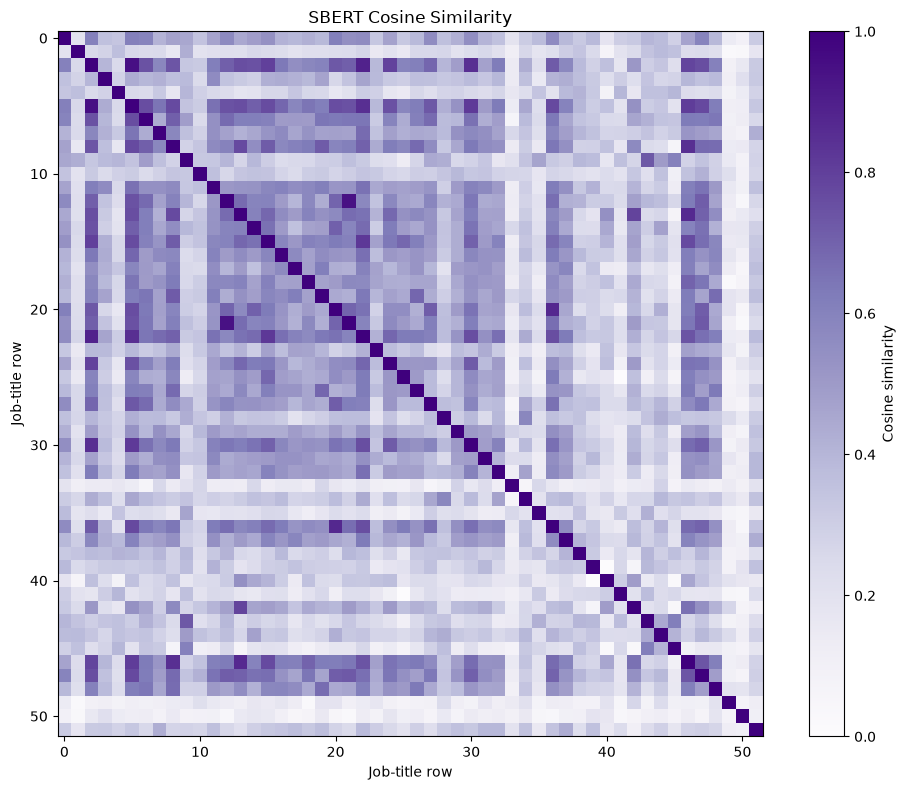

In [68]:
from sentence_transformers import SentenceTransformer

sbert_model_name = "sentence-transformers/all-MiniLM-L6-v2"
sbert_model = SentenceTransformer(sbert_model_name)

sbert_title_embeddings = sbert_model.encode(
    df_cleaned["job_title_cleaned"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=False,
)
sbert_query_embedding = sbert_model.encode(
    [search_query],
    normalize_embeddings=True,
    show_progress_bar=False,
)[0]
sbert_results = rank_dense_embeddings(
    sbert_title_embeddings,
    sbert_query_embedding,
    "sbert_similarity",
)
sbert_similarity_matrix = cosine_similarity(sbert_title_embeddings)

print("SBERT embedding shape:", sbert_title_embeddings.shape)
display(sbert_results.head(10))
plot_similarity_map(
    sbert_similarity_matrix,
    "SBERT Cosine Similarity",
    "Purples",
)


## 7. Re-ranking from recruiter feedback

A star should mean **“find more candidates like this one,”** not merely “add a bonus to this row.” The reranker therefore updates the SBERT query embedding:

```text
personalized query = original query
                   + centroid of starred candidates
                   - centroid of rejected candidates
```

Cosine similarity is recalculated for every candidate using the personalized query. A small direct-star bonus keeps explicitly selected candidates visible. Feedback is stored by search query so an HR preference does not contaminate a software-engineering search.


In [69]:
def unit_vector(vector):
    norm = np.linalg.norm(vector)
    return vector / norm if norm > 0 else vector


def rerank_with_relevance_feedback(
    query,
    starred_ids=None,
    rejected_ids=None,
    query_weight=0.60,
    starred_weight=0.40,
    rejected_weight=0.15,
    direct_star_bonus=0.03,
):
    starred_ids = list(starred_ids or [])
    rejected_ids = list(rejected_ids or [])

    known_ids = set(df_cleaned["id"])
    unknown_ids = (set(starred_ids) | set(rejected_ids)) - known_ids
    if unknown_ids:
        raise ValueError(f"Unknown candidate IDs: {sorted(unknown_ids)}")
    if set(starred_ids) & set(rejected_ids):
        raise ValueError("A candidate cannot be both starred and rejected.")

    original_query = sbert_model.encode(
        [query], normalize_embeddings=True, show_progress_bar=False
    )[0]
    personalized_query = query_weight * original_query

    if starred_ids:
        starred_mask = df_cleaned["id"].isin(starred_ids).to_numpy()
        starred_centroid = sbert_title_embeddings[starred_mask].mean(axis=0)
        personalized_query += starred_weight * unit_vector(starred_centroid)

    if rejected_ids:
        rejected_mask = df_cleaned["id"].isin(rejected_ids).to_numpy()
        rejected_centroid = sbert_title_embeddings[rejected_mask].mean(axis=0)
        personalized_query -= rejected_weight * unit_vector(rejected_centroid)

    personalized_query = unit_vector(personalized_query)
    initial_scores = sbert_title_embeddings @ original_query
    feedback_scores = sbert_title_embeddings @ personalized_query
    is_starred = df_cleaned["id"].isin(starred_ids).to_numpy()
    final_scores = feedback_scores + direct_star_bonus * is_starred

    results = df_cleaned[["id", "job_title"]].copy()
    results["is_starred"] = is_starred
    results["is_rejected"] = df_cleaned["id"].isin(rejected_ids).to_numpy()
    results["initial_similarity"] = initial_scores
    results["feedback_similarity"] = feedback_scores
    results["final_score"] = final_scores
    results["initial_rank"] = (
        results["initial_similarity"].rank(method="first", ascending=False).astype(int)
    )
    results["reranked_rank"] = (
        results["final_score"].rank(method="first", ascending=False).astype(int)
    )
    results["rank_change"] = results["initial_rank"] - results["reranked_rank"]

    return results.sort_values("reranked_rank").reset_index(drop=True)


### 7.1 Demonstration: one star, then two stars

Candidate 72 is first used as the recruiter’s ideal example. Candidate 76 is then added as a second positive example. Positive `rank_change` values mean a candidate moved upward.


In [70]:
feedback_by_query = {
    search_query: {
        "starred_ids": [72],
        "rejected_ids": [],
    }
}

current_feedback = feedback_by_query[search_query]
feedback_reranked = rerank_with_relevance_feedback(
    search_query,
    starred_ids=current_feedback["starred_ids"],
    rejected_ids=current_feedback["rejected_ids"],
)

print("First starred candidate:")
display(df_cleaned.loc[df_cleaned["id"].eq(72), ["id", "job_title"]])
print("Top 10 after one star:")
display(feedback_reranked.head(10))

largest_upward_moves = feedback_reranked.sort_values(
    ["rank_change", "final_score"], ascending=[False, False]
)
print("Candidates that moved upward most after the first star:")
display(largest_upward_moves.head(10))


First starred candidate:


,id,job_title
20,72,Business Management Major and Aspiring Human R...


Top 10 after one star:


,id,job_title,is_starred,is_rejected,initial_similarity,feedback_similarity,final_score,initial_rank,reranked_rank,rank_change
0,3,Aspiring Human Resources Professional,False,False,1.000000,0.955648,0.955648,1,1,0
1,6,Aspiring Human Resources Specialist,False,False,0.948665,0.936551,0.936551,2,2,0
2,72,Business Management Major and Aspiring Human R...,True,False,0.727237,0.897131,0.927131,13,3,10
3,74,Human Resources Professional,False,False,0.890226,0.853022,0.853022,3,4,-1
4,88,Human Resources Management Major,False,False,0.720463,0.835988,0.835988,14,5,9
5,82,Aspiring Human Resources Professional | An ene...,False,False,0.848948,0.826170,0.826170,4,6,-2
6,100,Aspiring Human Resources Manager | Graduating ...,False,False,0.755114,0.791352,0.791352,8,7,1
7,66,Experienced Retail Manager and aspiring Human ...,False,False,0.749743,0.784914,0.784914,10,8,2
8,67,"Human Resources, Staffing and Recruiting Profe...",False,False,0.799207,0.782943,0.782943,5,9,-4
9,99,Seeking Human Resources Position,False,False,0.783441,0.770128,0.770128,7,10,-3


Candidates that moved upward most after the first star:


,id,job_title,is_starred,is_rejected,initial_similarity,feedback_similarity,final_score,initial_rank,reranked_rank,rank_change
2,72,Business Management Major and Aspiring Human R...,True,False,0.727237,0.897131,0.927131,13,3,10
4,88,Human Resources Management Major,False,False,0.720463,0.835988,0.835988,14,5,9
10,27,Aspiring Human Resources Management student se...,False,False,0.707624,0.753545,0.753545,16,11,5
19,77,Human Resources|\nConflict Management|\nPolici...,False,False,0.593242,0.619806,0.619806,25,20,5
17,1,2019 C.T. Bauer College of Business Graduate (...,False,False,0.602796,0.650950,0.650950,22,18,4
34,96,Student at Indiana University Kokomo - Busines...,False,False,0.337873,0.398733,0.398733,39,35,4
11,73,"Aspiring Human Resources Manager, seeking inte...",False,False,0.707954,0.752514,0.752514,15,12,3
13,79,Liberal Arts Major. Aspiring Human Resources A...,False,False,0.690795,0.749694,0.749694,17,14,3
22,70,"Retired Army National Guard Recruiter, office ...",False,False,0.578307,0.584544,0.584544,26,23,3
23,8,HR Senior Specialist,False,False,0.578292,0.577584,0.577584,27,24,3


In [71]:
feedback_by_query[search_query]["starred_ids"].append(76)
current_feedback = feedback_by_query[search_query]

feedback_reranked_two_stars = rerank_with_relevance_feedback(
    search_query,
    starred_ids=current_feedback["starred_ids"],
    rejected_ids=current_feedback["rejected_ids"],
)

print("Starred candidates:")
display(
    df_cleaned.loc[
        df_cleaned["id"].isin(current_feedback["starred_ids"]),
        ["id", "job_title"],
    ]
)
print("Top 10 after two stars:")
display(feedback_reranked_two_stars.head(10))


Starred candidates:


,id,job_title
20,72,Business Management Major and Aspiring Human R...
24,76,Aspiring Human Resources Professional | Passio...


Top 10 after two stars:


,id,job_title,is_starred,is_rejected,initial_similarity,feedback_similarity,final_score,initial_rank,reranked_rank,rank_change
0,3,Aspiring Human Resources Professional,False,False,1.000000,0.977474,0.977474,1,1,0
1,6,Aspiring Human Resources Specialist,False,False,0.948665,0.943208,0.943208,2,2,0
2,76,Aspiring Human Resources Professional | Passio...,True,False,0.789880,0.855764,0.885764,6,3,3
3,74,Human Resources Professional,False,False,0.890226,0.868576,0.868576,3,4,-1
4,82,Aspiring Human Resources Professional | An ene...,False,False,0.848948,0.849994,0.849994,4,5,-1
5,72,Business Management Major and Aspiring Human R...,True,False,0.727237,0.816852,0.846852,13,6,7
6,67,"Human Resources, Staffing and Recruiting Profe...",False,False,0.799207,0.792272,0.792272,5,7,-2
7,100,Aspiring Human Resources Manager | Graduating ...,False,False,0.755114,0.787060,0.787060,8,8,0
8,99,Seeking Human Resources Position,False,False,0.783441,0.785180,0.785180,7,9,-2
9,88,Human Resources Management Major,False,False,0.720463,0.778868,0.778868,14,10,4


### 7.2 Optional rejection feedback

Pass candidate IDs through `rejected_ids` to move the personalized query away from those examples. Keep rejections separate from stars, record feedback per job requisition in a real application, and retain an audit log of who supplied each signal.


## 8. Compare all representations

Every model ranks the same 52 titles against the same recruiter query. `SBERT + feedback` is a reranking layer rather than a separate representation. Scores are comparable within a method, but their absolute values are not identical confidence scales across models.


In [72]:
model_comparison = df_cleaned[["job_title"]].copy()
model_comparison["bow"] = bow_results["cosine_similarity"]
model_comparison["tfidf"] = tfidf_results["cosine_similarity"]
model_comparison["word2vec"] = word2vec_results["word2vec_similarity"]
model_comparison["glove"] = glove_results["glove_similarity"]
model_comparison["fasttext"] = fasttext_results["fasttext_similarity"]
model_comparison["bert"] = bert_results["bert_similarity"]
model_comparison["sbert"] = sbert_results["sbert_similarity"]
feedback_scores_by_id = feedback_reranked_two_stars.set_index("id")["final_score"]
model_comparison["sbert_feedback"] = df_cleaned["id"].map(
    feedback_scores_by_id
)

model_comparison = model_comparison.sort_values("sbert_feedback", ascending=False)
display(model_comparison.head(15))

top_result_by_model = pd.DataFrame({
    "model": ["BoW", "TF-IDF", "Word2Vec", "GloVe", "FastText", "BERT", "SBERT", "SBERT + feedback"],
    "top_job_title": [
        bow_results.iloc[0]["job_title"],
        tfidf_results.iloc[0]["job_title"],
        word2vec_results.iloc[0]["job_title"],
        glove_results.iloc[0]["job_title"],
        fasttext_results.iloc[0]["job_title"],
        bert_results.iloc[0]["job_title"],
        sbert_results.iloc[0]["job_title"],
        feedback_reranked_two_stars.iloc[0]["job_title"],
    ],
    "top_similarity": [
        bow_results.iloc[0]["cosine_similarity"],
        tfidf_results.iloc[0]["cosine_similarity"],
        word2vec_results.iloc[0]["word2vec_similarity"],
        glove_results.iloc[0]["glove_similarity"],
        fasttext_results.iloc[0]["fasttext_similarity"],
        bert_results.iloc[0]["bert_similarity"],
        sbert_results.iloc[0]["sbert_similarity"],
        feedback_reranked_two_stars.iloc[0]["final_score"],
    ],
})

display(top_result_by_model)


,job_title,bow,tfidf,word2vec,glove,fasttext,bert,sbert,sbert_feedback
2,Aspiring Human Resources Professional,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.977474
5,Aspiring Human Resources Specialist,0.750000,0.522882,0.874233,0.761785,0.860993,0.965023,0.948665,0.943208
24,Aspiring Human Resources Professional | Passio...,0.516398,0.302742,0.668009,0.645069,0.641795,0.823593,0.789880,0.885764
22,Human Resources Professional,0.866025,0.823788,0.872890,0.876296,0.916173,0.966300,0.890226,0.868576
30,Aspiring Human Resources Professional | An ene...,0.632456,0.414161,0.739485,0.640346,0.814713,0.862519,0.848949,0.849994
20,Business Management Major and Aspiring Human R...,0.530330,0.320520,0.766594,0.654112,0.840490,0.897243,0.727237,0.846852
15,"Human Resources, Staffing and Recruiting Profe...",0.612372,0.402068,0.836280,0.723593,0.887897,0.885499,0.799207,0.792272
47,Aspiring Human Resources Manager | Graduating ...,0.545545,0.247188,0.751948,0.613904,0.751221,0.823838,0.755114,0.787060
46,Seeking Human Resources Position,0.500000,0.217853,0.705124,0.480069,0.736156,0.900918,0.783441,0.785180
36,Human Resources Management Major,0.500000,0.203565,0.737754,0.532463,0.795980,0.915347,0.720463,0.778868


,model,top_job_title,top_similarity
0,BoW,Aspiring Human Resources Professional,1.000000
1,TF-IDF,Aspiring Human Resources Professional,1.000000
2,Word2Vec,Aspiring Human Resources Professional,1.000000
3,GloVe,Aspiring Human Resources Professional,1.000000
4,FastText,Aspiring Human Resources Professional,1.000000
5,BERT,Aspiring Human Resources Professional,1.000000
6,SBERT,Aspiring Human Resources Professional,1.000000
7,SBERT + feedback,Aspiring Human Resources Professional,0.977474


## Current conclusion

- **Bag of Words** is the raw-count lexical baseline.
- **TF-IDF** downweights common corpus terms.
- **Word2Vec** learns local word-context relationships.
- **GloVe** learns from global word co-occurrence counts.
- **FastText** adds character subword information.
- **BERT** supplies contextual token embeddings that require pooling.
- **SBERT** directly supplies sentence embeddings designed for semantic similarity.
- **Relevance feedback** personalizes the SBERT query from recruiter stars and rejections, affecting similar candidates rather than only boosting the clicked row.

The locally trained Word2Vec, GloVe, and FastText models are educational demonstrations because 52 titles are not enough training data. For this project, TF-IDF is the strongest transparent lexical baseline and pretrained SBERT is the most appropriate semantic baseline. A meaningful final model choice requires labeled relevance judgments and ranking metrics such as Precision@K, Recall@K, MAP, or NDCG.
